# Figure 1: PI-NPZ Forecast Skill


In [1]:
%matplotlib inline
import importlib
import subprocess
import sys

def install_and_import(package):
    try:
        importlib.import_module(package)
    except ImportError:
        print(f"{package} not found, installing it now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    finally:
        globals()[package] = importlib.import_module(package)

# Standard library imports
import os
import time
import warnings

# Third-party imports
third_party_packages = ['numpy', 'pandas', 'matplotlib', 'scipy', 'sklearn', 'torch']

for package in third_party_packages:
    install_and_import(package)

# Specific imports from installed packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import odeint
from scipy.sparse.linalg import LinearOperator, cg
from scipy.linalg import eigvals
from scipy.optimize import brentq
from numpy import linalg as LA

import torch
from torch import nn

import lightning.pytorch as pl
from pytorch_lightning import seed_everything
from torch.utils.data import DataLoader, TensorDataset
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

import time
# Local imports
# Add the directory containing model_utils.py to the Python path
sys.path.append('../models')
from pi_npz import PhysicsInformedNN, DNN, forward_pinn
from traditional_npz import run_rk4_for_initial_conditions
sys.path.append('../utils')
from additional_files import calculate_rel_error, calculate_rmse, read_and_preprocess_data


In [3]:
num_threads = torch.get_num_threads()
torch.set_num_threads(num_threads)

# CPU device
dtype = torch.float64
device = torch.device('cpu') # Smaller models/data, running on CPU

dataset_dir = 'data/training_validation_data'
dataset_path = f'{dataset_dir}/npz_training_set.csv'
x, u, nd_ntot = read_and_preprocess_data(f"../{dataset_path}",device='cpu')


Reading CSV file...
CSV file read successfully


In [4]:
# Load Model Checkpoint
checkpoint_dir = 'model_checkpoints'
model_ckpt_name = 'pi_npz_final.ckpt'
checkpoint_path = f"../{checkpoint_dir}/{model_ckpt_name}"

# Non-dimensionalization
t_scale = 1.0
alpha_tilde = 1.2164 * t_scale
beta_tilde = 1.2795 * nd_ntot
b_tilde = 0.1 * t_scale
c_tilde = 0.2 * t_scale
e_tilde = 0.5 * t_scale * nd_ntot
f_tilde = 0.5 * t_scale * nd_ntot
# Define parameters for GELU model
params_dict = {
'alpha_tilde': torch.tensor([alpha_tilde], dtype=dtype),
'beta_tilde': torch.tensor([beta_tilde], dtype=dtype),
'b_tilde': torch.tensor([b_tilde], dtype=dtype),
'c_tilde': torch.tensor([c_tilde], dtype=dtype),
'e_tilde': torch.tensor([e_tilde], dtype=dtype),
'f_tilde': torch.tensor([f_tilde], dtype=dtype),
}

learning_rate = 0.0006
num_layers = 5
num_neurons = 384
activation_function = nn.GELU

# Step 1: Load the checkpoint manually
checkpoint = torch.load(checkpoint_path, map_location="cpu")

# Step 2: Reconstruct the model using the same init args
pi_npz_model = PhysicsInformedNN(
    DNN=DNN,
    num_layers=num_layers,
    num_neurons=num_neurons,
    activation_function=activation_function,
    params_dict=params_dict,
    lambda_u=1,
    lambda_f=1,
    learning_rate=learning_rate,
    dtype=dtype
)

# Step 3: Load the model weights from the checkpoint
pi_npz_model.load_state_dict(checkpoint["state_dict"])

# Step 4: Optional – move to float64
pi_npz_model = pi_npz_model.to(torch.float64)


## Forward Modeling with PINN

In [5]:
total_days = 7 # / 24

intervals_per_day = 24 * 2 * 3 # 10 minute intervals

# Calculate the total number of half-hour intervals
total_intervals = total_days * intervals_per_day

# Create an array from 0 to 7 days with half-hour intervals
times = np.arange(0, total_days + 1/intervals_per_day, 1/intervals_per_day)

if times[-1] > total_days:
    times = times[:-1]

In [7]:
# Step 5: Convert to torch tensor
# # Load dataset
test_set_initial_states = pd.read_csv("../data/training_validation_data/npz_test_set.csv", index_col=False)
test_set_initial_states = test_set_initial_states[['N', 'P', 'Z']].values

test_set_initial_states_tensor = torch.tensor(test_set_initial_states, device=device, dtype=dtype)

# Confirm
print(f"Selected {len(test_set_initial_states_tensor)} samples in [1.8, 2.2] with all components >= 0.1")
print(f"New mean total N: {test_set_initial_states_tensor.sum(dim=1).mean().item():.4f}")


Selected 10000 samples in [1.8, 2.2] with all components >= 0.1
New mean total N: 2.0501


In [8]:
from joblib import Parallel, delayed
import datetime
# # Wrap the callable for each job
def run_forward_pinn_single(x0, nd_ntot, times):
    # reconstruct or load model inside worker if needed
    global pi_npz_model
    pred = forward_pinn(pi_npz_model, x0, nd_ntot, times).detach().numpy()
    return pred

# Run in parallel
n_jobs = 6
start_time = time.time()
print(f"Start time: {start_time}")
dt = datetime.datetime.fromtimestamp(start_time)  # local time
dt_utc = datetime.datetime.fromtimestamp(start_time)  # UTC

print("Local time:", dt)
print("UTC time:", dt_utc)
test_forward_predictions_list = Parallel(n_jobs=n_jobs)(
    delayed(run_forward_pinn_single)(x0, nd_ntot, times)
    for x0 in test_set_initial_states_tensor
)
end_time = time.time()
pinn_prediction_loop_time = end_time - start_time
print(f"Running time: {pinn_prediction_loop_time:.2f} sec ({pinn_prediction_loop_time/60:.2f} min)")


Start time: 1762395344.910285
Local time: 2025-11-05 16:15:44.910285
UTC time: 2025-11-05 16:15:44.910285
Running time: 418.64 sec (6.98 min)


In [9]:
# Define system parameters
Vm = 2
ks = 1
m = 0.1
gamma = 0.3
Rm = 1.5
ivlev = 1
q = 0.2
phi = (Vm, ks, m, Rm, ivlev, gamma, q)

# Define time parameters
tstart = 0
minutes_per_step = 10
minutes_per_hour = 60
hours_per_day = 24
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
t = np.arange(tstart, total_days + dt, dt)

# Define training time intervals
intervals_per_day = 24 * 2 * 3  # Half-hour intervals
times_train = np.arange(0, total_days + 1 / intervals_per_day, 1 / intervals_per_day)
if times_train[-1] > total_days:
    times_train = times_train[:-1]

# Worker function
def rk4_worker(ic):
    N0, P0, Z0 = ic
    xt_result = run_rk4_for_initial_conditions(N0, P0, Z0, t, phi)
    xt_array = np.column_stack((t, xt_result[:, 0], xt_result[:, 1], xt_result[:, 2]))
    matching_indices = np.searchsorted(t, times_train)
    xt_matching_rows = xt_array[matching_indices]
    return xt_matching_rows[:, 1:]  # Only N, P, Z columns

# Run in parallel
start_time = time.time()
test_xt_results = Parallel(n_jobs=-1, backend="loky")(
    delayed(rk4_worker)(ic) for ic in test_set_initial_states_tensor.numpy()
)
end_time = time.time()

rk4_prediction_loop_time = end_time - start_time
print(f"Running time: {rk4_prediction_loop_time:.2f} seconds")


Running time: 33.80 seconds


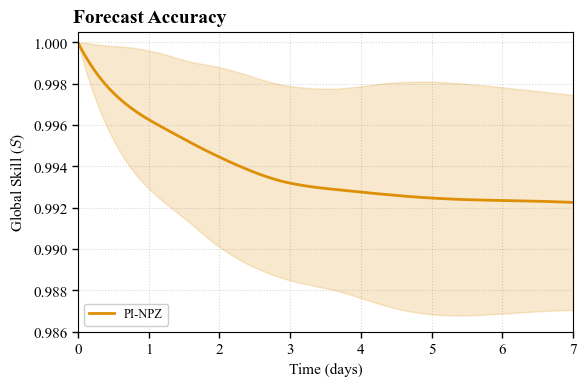

In [11]:
test_forward_actuals = [np.array(gt) for gt in test_xt_results]  # No slicing!

test_forward_preds = np.array(test_forward_predictions_list)  # Shape: [N, T, 3]
test_forward_truths = np.array(test_forward_actuals)          # Shape: [N, T, 3]


test_skill_scores = 1 - (np.abs(test_forward_preds - test_forward_truths) / np.abs(test_forward_truths))

# Now aggregate: mean and std over all trajectories (axis=0)
# Resulting shapes: (num_time_steps, num_vars)
test_skill_mean = np.nanmean(test_skill_scores, axis=0)
test_skill_std = np.nanstd(test_skill_scores, axis=0)

# Transpose to: skill_mean[var][t]
test_skill_mean = test_skill_mean.T  # Shape: (3, num_time_steps)
test_skill_std = test_skill_std.T    # Shape: (3, num_time_steps)
# Typography for JAMES publication
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False

# Axis and tick styling
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'


# Color scheme
skill_color = "#DE8F05" #"#333333"

STEP_MINUTES = 10
T_steps = 1000
N_trajectories = test_set_initial_states.shape[0]

# === Skill calculations ===
total_skill_per_trajectory = np.nanmean(test_skill_scores, axis=2)  # shape (N, T)
total_skill_mean = np.nanmean(total_skill_per_trajectory, axis=0)
total_skill_std = np.nanstd(total_skill_per_trajectory, axis=0)

# Time vector
times = np.linspace(0, 7, total_skill_mean.shape[0])

# Bounds for shading
lower = np.clip(total_skill_mean - total_skill_std, 0.0, None)
upper = np.minimum(total_skill_mean + total_skill_std, 1.0)

# === Single-panel figure ===
fig, ax = plt.subplots(figsize=(6, 4))  # Keep your original size

# Plot mean and uncertainty
line = ax.plot(times, total_skill_mean, color=skill_color, linewidth=2, label='PI-NPZ')
shade = ax.fill_between(times, lower, upper, color=skill_color, alpha=0.2)#, label='±1σ')

# Optional: Add 99% threshold line if relevant
# ax.axhline(0.99, color=threshold_99_color, linestyle='--', linewidth=1, alpha=0.7, label='τ = 0.99')

# Labels with appropriate font sizes
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Global Skill ($S$)", fontsize=11)  # More specific label

# Set axis limits
ax.set_xlim(0, 7)
ax.set_ylim(0.986, 1.0005)

# Format y-axis to show 3 decimal places for clarity
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}'))

# Grid (subtle)
ax.grid(True, linestyle=':', alpha=0.3, color='gray')
# ax.minorticks_on()
ax.tick_params(direction='out', length=4, width=1, color='black')

# Add legend (ESSENTIAL for publication)
ax.legend(loc='lower left', fontsize=9, framealpha=0.95)

# Title - keeping as in original
ax.text(-0.01, 1.02, 'Forecast Accuracy', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='left', va='bottom')

plt.tight_layout()

# # === Save ===
# base_path = "../figures/"
# file_base = f"forecast_skill"

# # Save as vector format (PDF) for publication and PNG for review
# for ext in ["pdf"]:
#     if ext == "png":
#         dpi = 600  # High DPI for raster
#     else:
#         dpi = None  # Vector formats don't need DPI
#     plt.savefig(f"{base_path}{file_base}.{ext}", 
#                 dpi=dpi, 
#                 bbox_inches='tight', 
#                 pad_inches=0.02,
#                 format=ext)

plt.show()

